## Importing Libraries

In [ ]:
# All needed libraries will be added to this cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import calendar
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="talk")

---

## Importing & Reading Data

In [2]:
# Building the importing & reading function
# This function is built to avoid any reptation in the code
def read_data(df: pd.DataFrame, name: str = "Dataset"):

    # Making bold Markdown header for the dataset and adding separator line
    display(Markdown(f"## Dataset Overview: **{name}**"))
    display(Markdown("---"))
    
    # Output the Shape of the DataFrame to tell us the overall size
    display(Markdown(f"**🔹 Shape:** `{df.shape[0]}` rows * `{df.shape[1]}` columns"))
    
    # Output the Column Names to check the available features
    display(Markdown(f"**🔹 Columns Names:** {list(df.columns)}"))
    
    # Create a combined Summary Table for Data Types and Missing Values
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isna().sum(),
        '% of Missing Values': (df.isna().sum() / len(df) * 100).round(2)
    })
    display(Markdown("**🔹 Data Types & Missing Values:**"))
    display(summary_df)
    
    # Output the start of the data 
    display(Markdown("**🔹 First 5 Rows:**"))
    display(df.head(5))
    
    # Output the end of the data 
    display(Markdown("**🔹 Last 5 Rows:**"))
    display(df.tail(5))
    
    # Basic Statistical Summary
    display(Markdown("**🔹 Basic Statistics (Numerical Columns):**"))
    display(df.describe().round(2))

In [3]:
# Read the data 
df_gdp = pd.read_excel('../data/Monthly_GDP.xlsx')
df_gt = pd.read_csv('../data/google_trends_categories.csv')

In [4]:
# Execute the function on first dataset
read_data(df_gdp, "Monthly GDP")

## Dataset Overview: **Monthly GDP**

---

**🔹 Shape:** `145` rows * `2` columns

**🔹 Columns Names:** ['Date', 'Monthly GDP']

**🔹 Data Types & Missing Values:**

...

,Date,Monthly GDP
0,2013-07-01,449.570584
1,2013-08-01,448.920708
2,2013-09-01,452.618708
3,2013-10-01,456.842549
4,2013-11-01,456.478571


**🔹 Last 5 Rows:**

,Date,Monthly GDP
140,2025-03-01,693.765650
141,2025-04-01,710.078987
142,2025-05-01,721.935668
143,2025-06-01,724.285345
144,2025-07-01,722.505363


**🔹 Basic Statistics (Numerical Columns):**

,Date,Monthly GDP
count,145,145.00
mean,2019-07-02 01:09:31.034482,585.25
min,2013-07-01 00:00:00,438.41
25%,2016-07-01 00:00:00,504.01
50%,2019-07-01 00:00:00,580.95
75%,2022-07-01 00:00:00,660.52
max,2025-07-01 00:00:00,754.23
std,NaN,89.06


In [5]:
# Execute the function on second dataset
read_data(df_gt, "Google Trends Categories")

## Dataset Overview: **Google Trends Categories**

---

**🔹 Shape:** `146` rows * `17` columns

**🔹 Columns Names:** ['date', 'Arts & Entertainment', 'Autos & Vehicles', 'Beauty & Fitness', 'Books & Literature', 'Business & Industrial', 'Computers & Electronics', 'Finance', 'Food & Drink', 'Health', 'Internet & Telecom', 'Jobs & Education', 'Law & Government', 'People & Society', 'Real Estate', 'Shopping', 'Travel']

**🔹 Data Types & Missing Values:**

...

,date,Arts & Entertainment,Autos & Vehicles,Beauty & Fitness,Books & Literature,Business & Industrial,Computers & Electronics,Finance,Food & Drink,Health,Internet & Telecom,Jobs & Education,Law & Government,People & Society,Real Estate,Shopping,Travel
0,2013-07,96,92,54,42,40,75,7,52,24,97,55,67,63,28,39,32
1,2013-08,94,93,54,39,35,77,7,41,25,96,33,62,57,33,44,42
2,2013-09,80,90,54,38,39,73,7,41,26,99,37,57,46,37,42,40
3,2013-10,75,83,48,34,37,73,6,37,26,90,21,46,41,33,40,33
4,2013-11,75,84,46,39,38,75,7,41,31,91,22,49,44,35,42,33


**🔹 Last 5 Rows:**

,date,Arts & Entertainment,Autos & Vehicles,Beauty & Fitness,Books & Literature,Business & Industrial,Computers & Electronics,Finance,Food & Drink,Health,Internet & Telecom,Jobs & Education,Law & Government,People & Society,Real Estate,Shopping,Travel
141,2025-04,62,73,86,56,85,80,44,73,91,74,34,73,68,87,90,81
142,2025-05,58,66,87,55,100,86,42,74,91,73,42,82,67,81,94,88
143,2025-06,60,77,91,54,95,82,41,79,89,74,51,82,68,88,100,89
144,2025-07,57,73,89,53,89,87,37,71,88,78,52,76,62,90,90,76
145,2025-08,54,72,82,52,81,84,37,74,82,73,50,71,64,87,85,92


**🔹 Basic Statistics (Numerical Columns):**

,Arts & Entertainment,Autos & Vehicles,Beauty & Fitness,Books & Literature,Business & Industrial,Computers & Electronics,Finance,Food & Drink,Health,Internet & Telecom,Jobs & Education,Law & Government,People & Society,Real Estate,Shopping,Travel
count,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00,146.00
mean,66.23,72.55,64.95,47.22,63.23,66.55,24.55,62.29,60.97,72.23,36.04,62.05,55.40,65.88,67.03,59.34
std,12.88,11.12,15.34,8.22,16.28,10.60,17.08,12.30,22.69,10.50,10.71,10.58,12.79,17.07,16.96,16.55
min,47.00,47.00,45.00,34.00,35.00,46.00,6.00,37.00,24.00,54.00,18.00,42.00,37.00,28.00,39.00,32.00
25%,57.00,64.00,53.00,41.25,49.00,58.25,13.00,52.00,43.00,64.00,27.00,54.00,46.00,52.25,51.25,45.00
50%,61.00,72.50,59.00,45.00,61.00,65.00,19.00,61.00,54.00,72.00,34.50,60.00,52.00,68.00,65.00,58.50
75%,77.00,81.00,79.75,51.75,77.75,75.75,37.00,73.75,84.75,77.00,43.75,70.00,64.75,80.00,82.75,70.75
max,97.00,100.00,100.00,100.00,100.00,90.00,100.00,100.00,100.00,100.00,69.00,85.00,100.00,100.00,100.00,100.00


---

## Data Analysis & Visualization

### Monthly_GDP Dataset

In [6]:
# Create a clean copy from your existing df_gdp dataset for visulaization only
df_gdp_visualization = df_gdp.copy()

In [7]:
# make sure that the Date column is properly formatted and set it as the index
df_gdp_visualization['Date'] = pd.to_datetime(df_gdp_visualization['Date'])
df_gdp_visualization = df_gdp_visualization.sort_values('Date')
df_gdp_visualization.set_index('Date', inplace=True)

In [8]:
# Add Month-over-Month Growth Rate and Time Feature for charting
df_gdp_visualization['MoM_Growth'] = df_gdp_visualization['Monthly GDP'].pct_change() * 100
df_gdp_visualization['Month'] = df_gdp_visualization.index.month

In [9]:
df_gdp_visualization.head()

,Monthly GDP,MoM_Growth,Month
Date,,,
2013-07-01,449.570584,NaN,7
2013-08-01,448.920708,-0.144555,8
2013-09-01,452.618708,0.823753,9
2013-10-01,456.842549,0.933201,10
2013-11-01,456.478571,-0.079673,11


In [26]:
# Function to avoid repetitive styling code
def apply_chart_styling(title, ylabel, xlabel='Year'):
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

yearly_dates = pd.date_range(start='2013-01-01', end='2025-01-01', freq='YS')

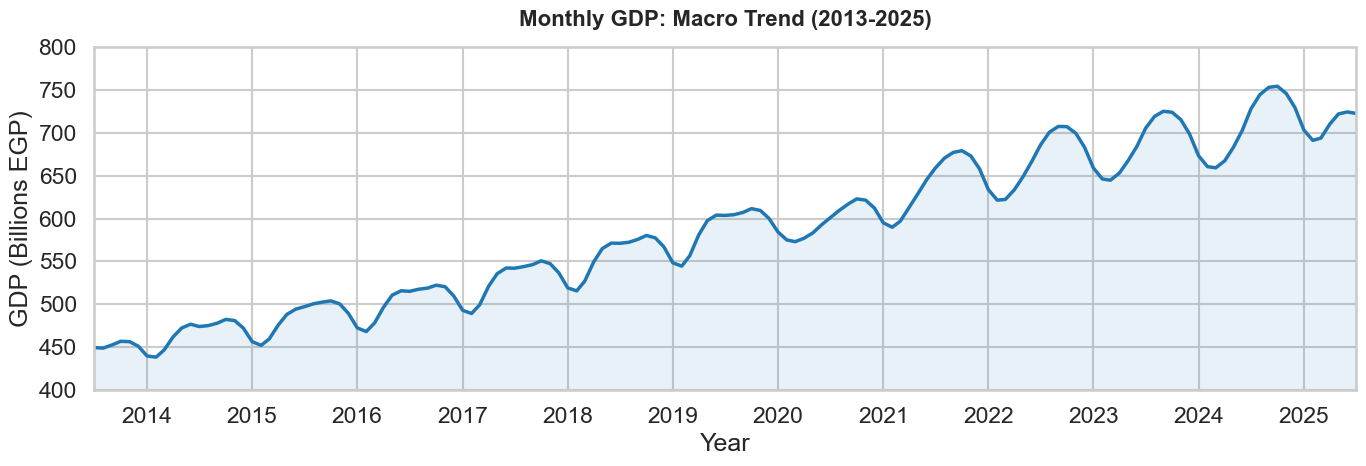

In [27]:
# CHART 1: The Macro Trend
plt.figure(figsize=(14, 5))

# Plot the lines and fill
plt.plot(df_gdp_visualization.index, df_gdp_visualization['Monthly GDP'], color='#1f77b4', linewidth=2.5)
plt.fill_between(df_gdp_visualization.index, df_gdp_visualization['Monthly GDP'], alpha=0.1, color='#1f77b4')

# Axis 
plt.yticks(range(400, 801, 50))
plt.xticks(yearly_dates, yearly_dates.year)

# Remove the empty space)
plt.ylim(bottom=400) 
plt.margins(x=0)

# Apply styling function
apply_chart_styling('Monthly GDP: Macro Trend (2013-2025)', 'GDP (Billions EGP)')

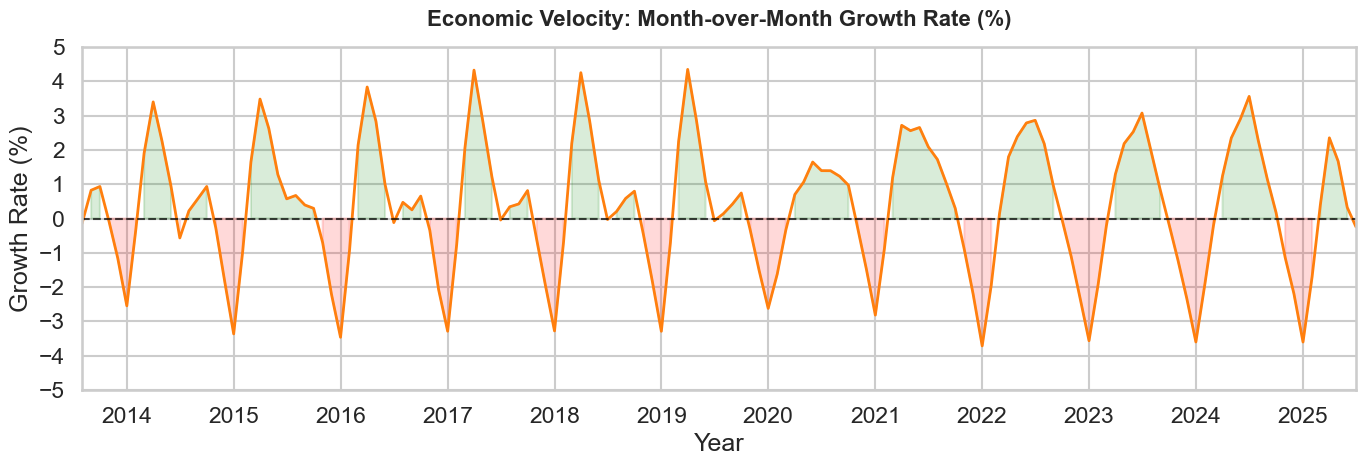

In [28]:
# CHART 2: Economic Velocity 
plt.figure(figsize=(14, 5))

# Plot the lines and fill
plt.plot(df_gdp_visualization.index, df_gdp_visualization['MoM_Growth'], color='#ff7f0e', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1.5)

# Green for expansion, Red for contraction
plt.fill_between(df_gdp_visualization.index, df_gdp_visualization['MoM_Growth'], 0,
                 where=df_gdp_visualization['MoM_Growth'] >= 0,
                 color='green', alpha=0.15)
plt.fill_between(df_gdp_visualization.index, df_gdp_visualization['MoM_Growth'], 0,
                 where=df_gdp_visualization['MoM_Growth'] < 0,
                 color='red', alpha=0.15)

# Axis 
plt.yticks(range(-5, 6, 1))
plt.xticks(yearly_dates, yearly_dates.year)

# Remove the empty space
plt.margins(x=0)

# Apply styling function
apply_chart_styling('Economic Velocity: Month-over-Month Growth Rate (%)', 'Growth Rate (%)')


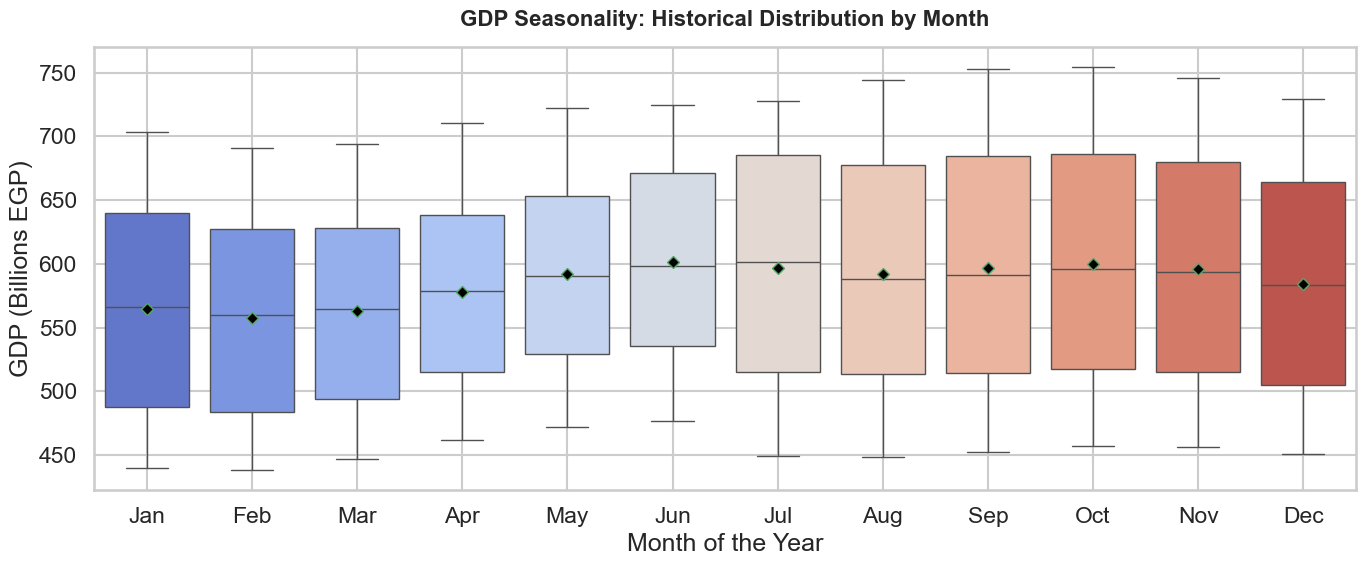

In [29]:
# CHART 3: Seasonality Boxplot
plt.figure(figsize=(14, 6))

# Plot
sns.boxplot(x='Month', y='Monthly GDP', data=df_gdp_visualization,
            palette='coolwarm', showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "black", "markersize": 6})

# Axis 
plt.xticks(ticks=range(12), labels=[calendar.month_abbr[i] for i in range(1, 13)])

# Apply styling function
apply_chart_styling('GDP Seasonality: Historical Distribution by Month', 'GDP (Billions EGP)', 'Month of the Year')

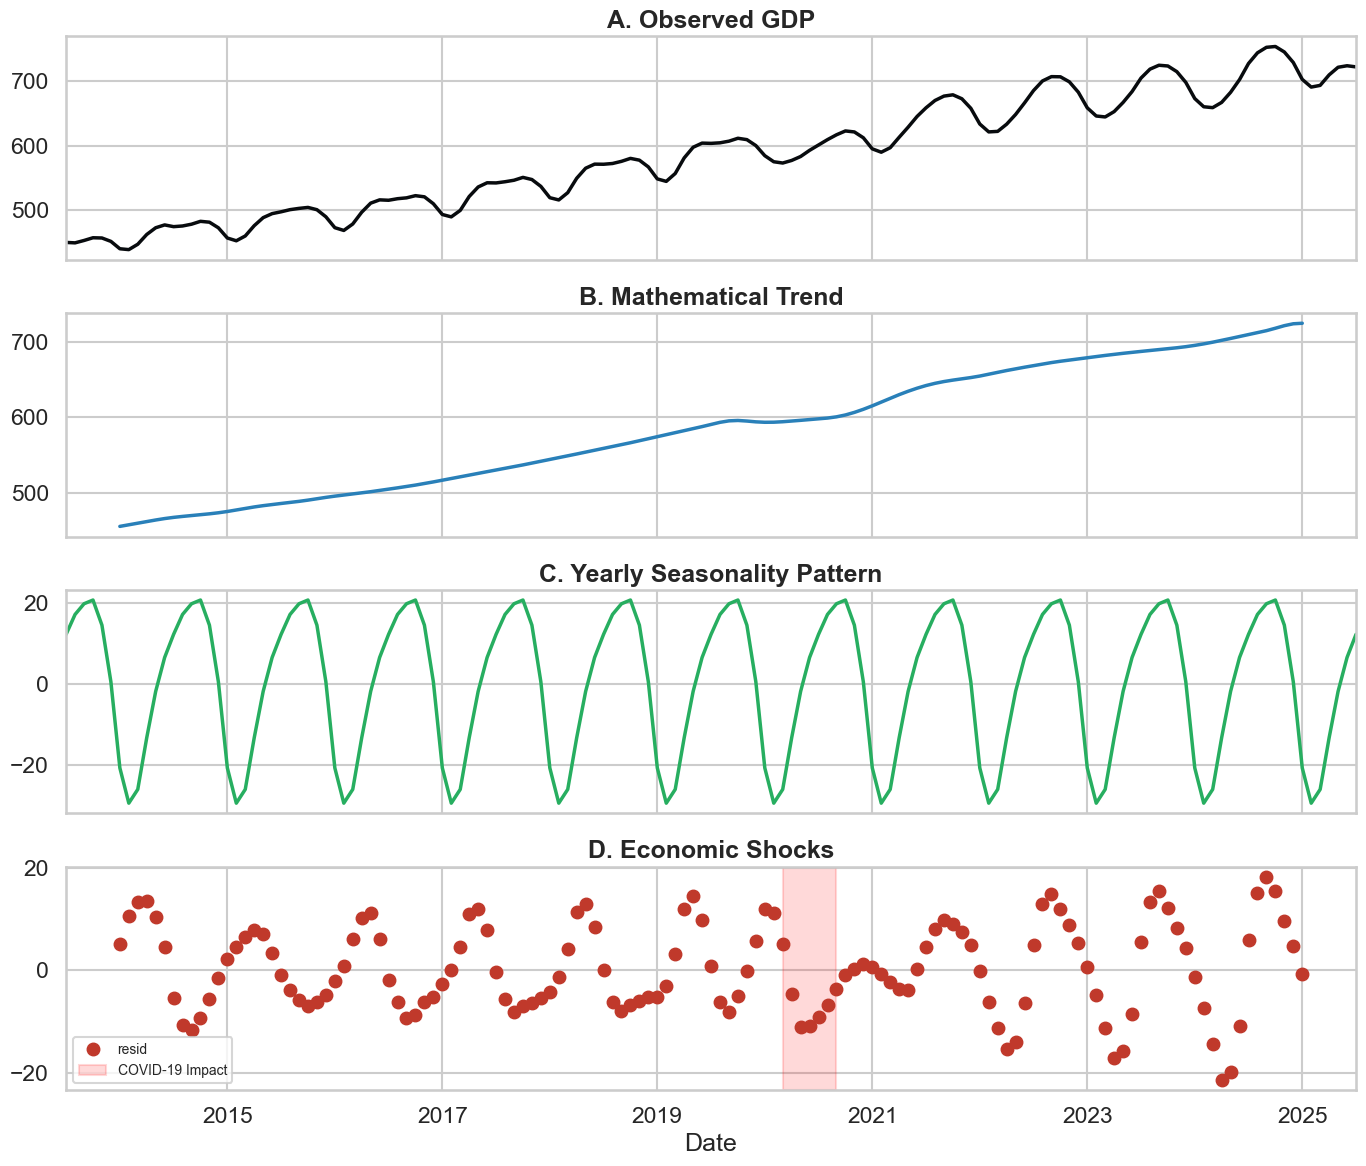

In [34]:
# CHART 4: Time-Series Decomposition

decomposition = seasonal_decompose(df_gdp_visualization['Monthly GDP'].dropna(), model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

decomposition.observed.plot(ax=axes[0], color="#080b0e", linewidth=2.5)
axes[0].set_title('A. Observed GDP', fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='#2980b9', linewidth=2.5)
axes[1].set_title('B. Mathematical Trend', fontweight='bold')

decomposition.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=2.5)
axes[2].set_title('C. Yearly Seasonality Pattern', fontweight='bold')

decomposition.resid.plot(ax=axes[3], color='#c0392b', marker='o', linestyle='none')
axes[3].set_title('D. Economic Shocks', fontweight='bold')
axes[3].axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2020-09'),
                alpha=0.15, color='red', label='COVID-19 Impact')
axes[3].legend(fontsize=10)

plt.tight_layout()
plt.show()

### Google Trends Dataset

In [35]:
# Create a clean copy from your existing df_gt dataset for visulaization only
df_gt_vis = df_gt.copy()
df_gt_vis['date'] = pd.to_datetime(df_gt_vis['date'])
df_gt_vis = df_gt_vis.sort_values('date')
df_gt_vis.set_index('date', inplace=True)

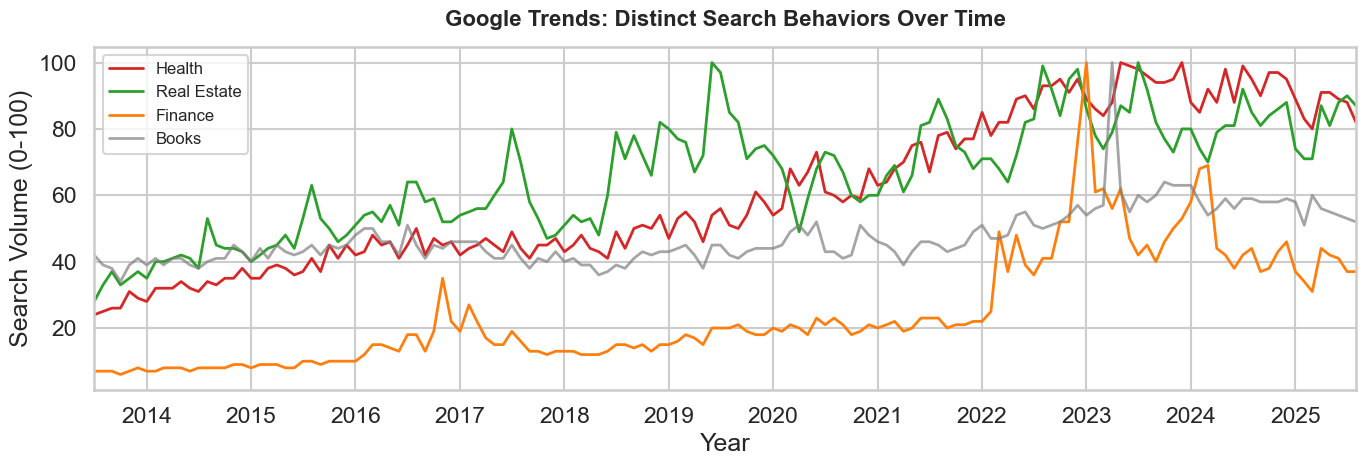

In [40]:
# CHART 1: Time Series of Distinct Behaviors
plt.figure(figsize=(14, 5))

plt.plot(df_gt_vis.index, df_gt_vis['Health'], label='Health', color='#d62728', linewidth=2)
plt.plot(df_gt_vis.index, df_gt_vis['Real Estate'], label='Real Estate', color='#2ca02c', linewidth=2)
plt.plot(df_gt_vis.index, df_gt_vis['Finance'], label='Finance', color='#ff7f0e', linewidth=2)
plt.plot(df_gt_vis.index, df_gt_vis['Books & Literature'], label='Books', color='#7f7f7f', linewidth=2, alpha=0.7)

# Axis 
plt.xticks(yearly_dates, yearly_dates.year)
plt.legend(loc='upper left', fontsize=12)

# Remove the empty space
plt.margins(x=0)

# Apply styling function
apply_chart_styling('Google Trends: Distinct Search Behaviors Over Time', 'Search Volume (0-100)')


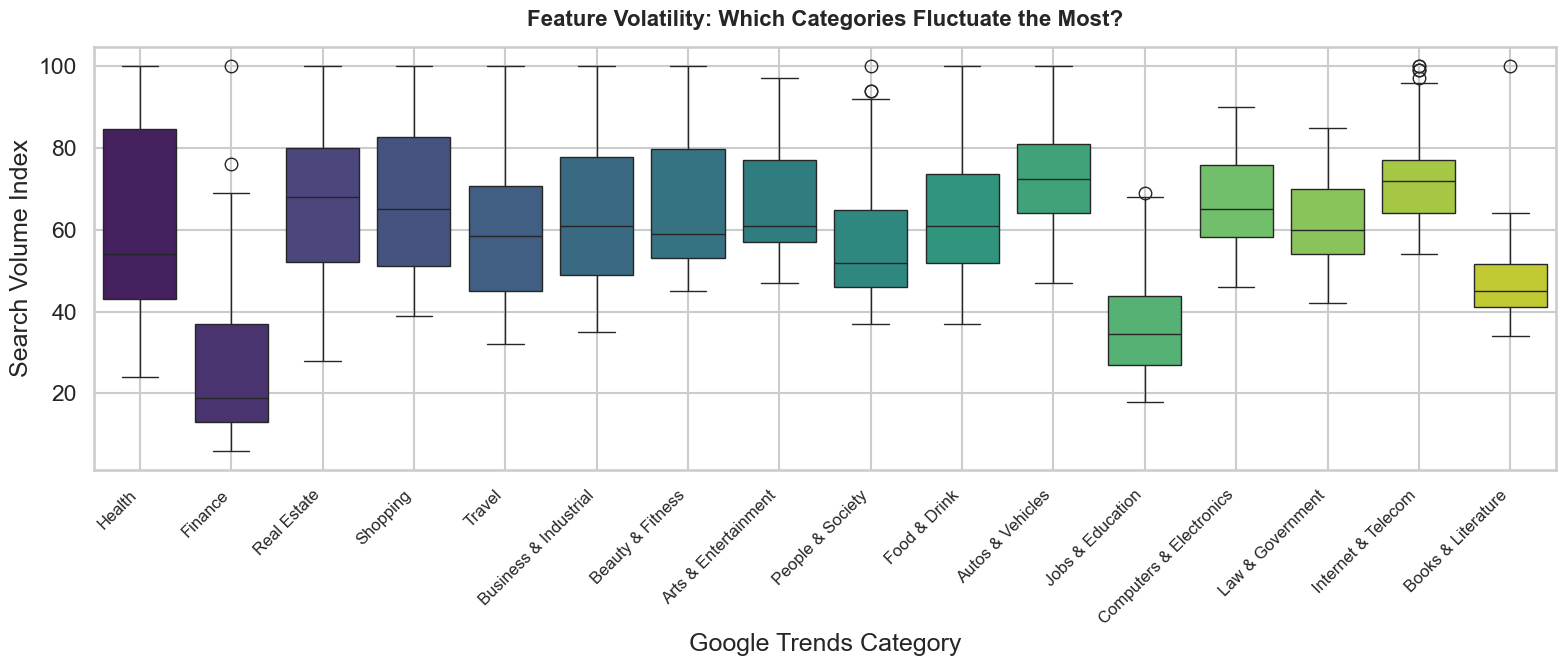

In [37]:
# CHART 2: Volatility Distribution
plt.figure(figsize=(16, 7))

# Sort the categories by how wildly they fluctuate (Standard Deviation)
sorted_by_volatility = df_gt_vis.std().sort_values(ascending=False).index
sns.boxplot(data=df_gt_vis[sorted_by_volatility], palette="viridis")

# Axis 
plt.xticks(rotation=45, ha='right', fontsize=12)

# Apply styling function
apply_chart_styling('Feature Volatility: Which Categories Fluctuate the Most?', 'Search Volume Index', xlabel='Google Trends Category')

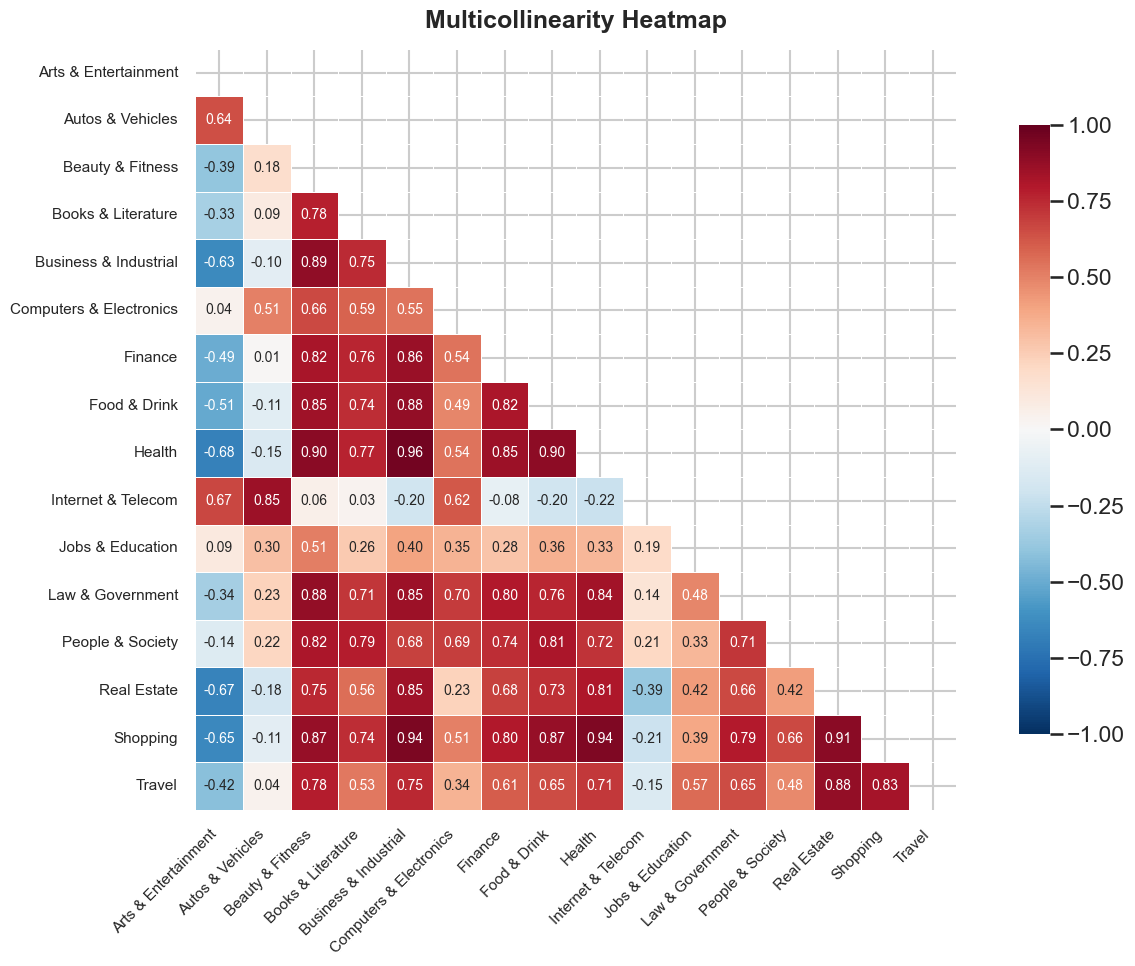

In [38]:
# CHART 3: Multicollinearity Heatmap 
plt.figure(figsize=(14, 10))

corr_matrix = df_gt_vis.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, annot_kws={"size": 10})

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.title('Multicollinearity Heatmap', fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


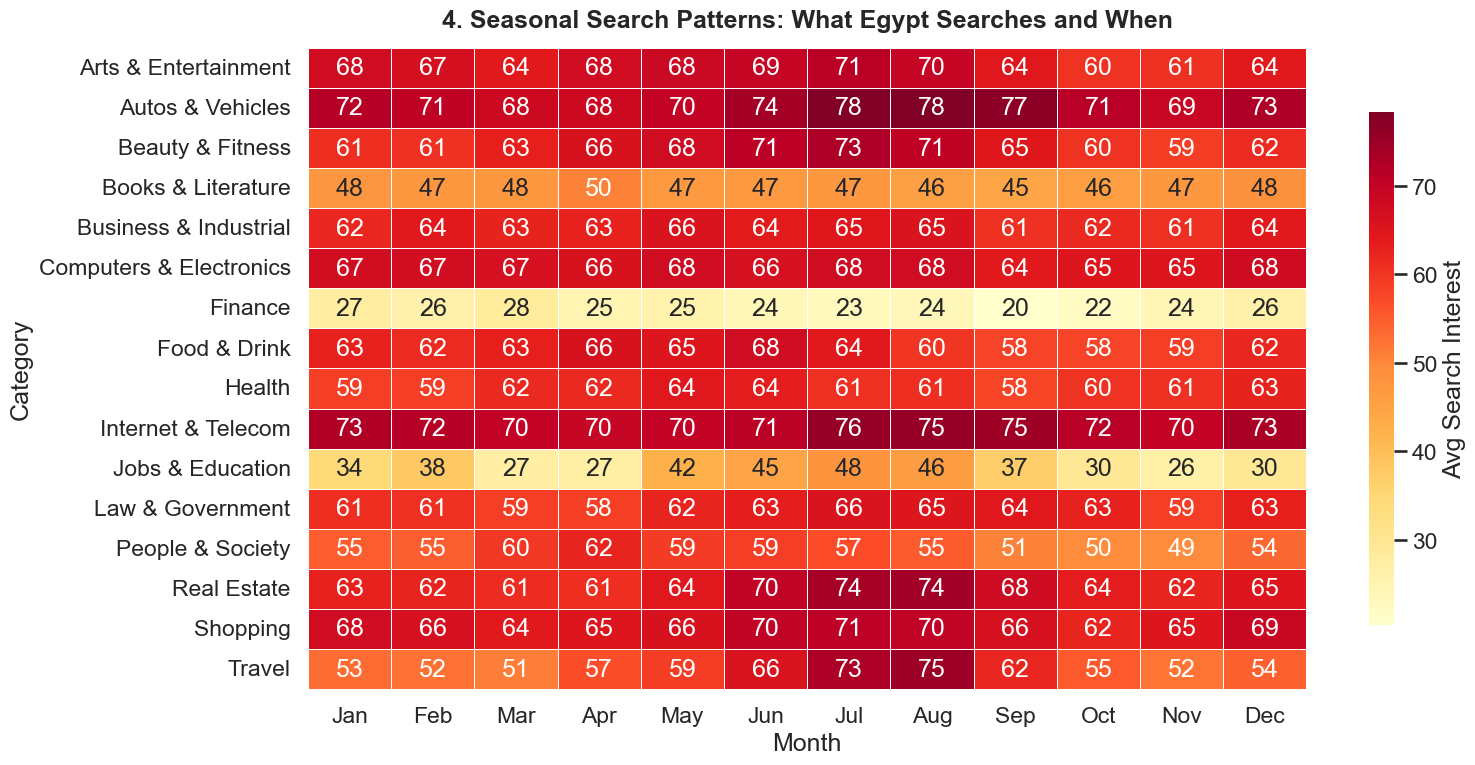

In [ ]:
# CHART 4: Seasonal Heatmap — When does Egypt search for what?
plt.figure(figsize=(16, 8))

# Get the average search interest per month for each category
categories = [col for col in df_gt_vis.columns]  
monthly_avg = df_gt_vis.copy()
monthly_avg['month'] = df_gt_vis.index.month
seasonal_pattern = monthly_avg.groupby('month')[categories].mean()

# Rename index to month names for readability
seasonal_pattern.index = [calendar.month_abbr[m] for m in seasonal_pattern.index]

sns.heatmap(seasonal_pattern.T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Avg Search Interest"})

plt.title('4. Seasonal Search Patterns: What Egypt Searches and When',
          fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Category')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

### Merged Dataset

In [41]:
df_gdp_prep = df_gdp.copy()
df_gdp_prep['Date'] = pd.to_datetime(df_gdp_prep['Date'])
df_gdp_prep.set_index('Date', inplace=True)

In [42]:
df_gt_prep = df_gt.copy()
df_gt_prep['date'] = pd.to_datetime(df_gt_prep['date'])
df_gt_prep.set_index('date', inplace=True)

In [43]:
df_merged = pd.merge(df_gt_prep, df_gdp_prep[['Monthly GDP']],
                      left_index=True, right_index=True, how='inner')

gt_categories = df_gt_prep.columns

In [44]:
print(f"Merged: {df_merged.shape[0]} months × {df_merged.shape[1]} columns")
print(f"Range:  {df_merged.index.min().strftime('%Y-%m')} → {df_merged.index.max().strftime('%Y-%m')}")

Merged: 145 months × 17 columns
Range:  2013-07 → 2025-07


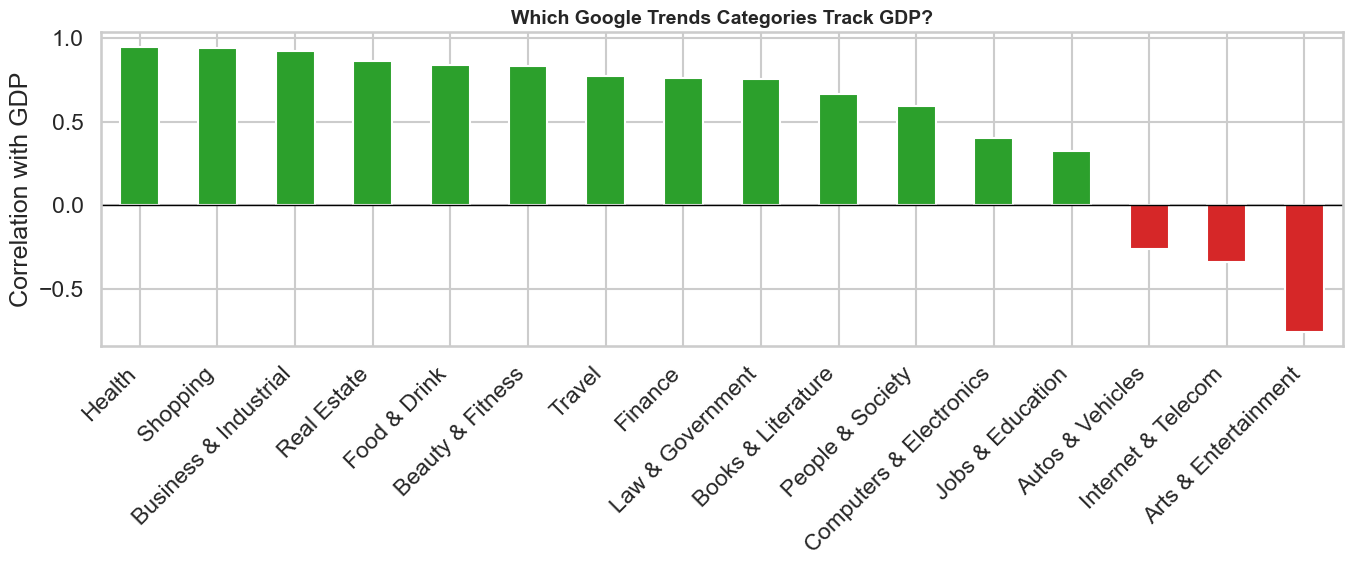

In [54]:
# CHART 1: Which categories correlate with GDP?

# Calculate Pearson correlation between each category and GDP
corr_level = df_merged[gt_categories].apply(
    lambda x: x.corr(df_merged['Monthly GDP'])
).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Green for positive correlation, Red for negative
colors = ['#2ca02c' if c > 0 else '#d62728' for c in corr_level]
corr_level.plot(kind='bar', color=colors, ax=ax)

# Styling
ax.set_ylabel('Correlation with GDP')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Which Google Trends Categories Track GDP?', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

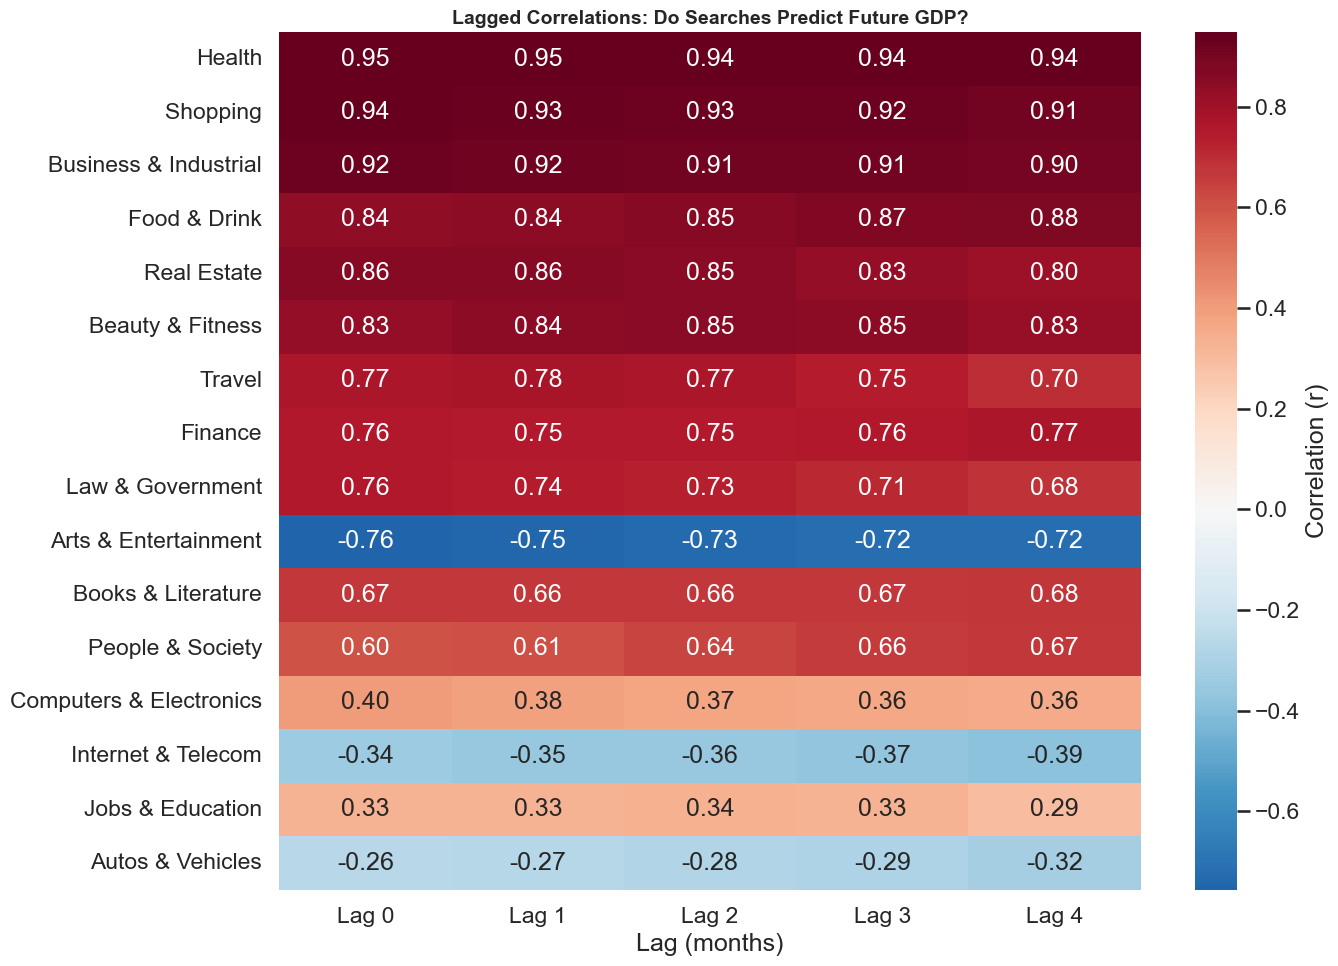

In [55]:
# CHART 2: Lagged Correlation — Do searches PREDICT GDP?
max_lag = 4

# Calculate correlation at each lag for every category
lag_corr = {}
for col in gt_categories:
    lag_corr[col] = [
        df_merged[col].shift(lag).corr(df_merged['Monthly GDP']) 
        for lag in range(max_lag + 1)
    ]

# Build DataFrame and sort by strongest absolute correlation
df_lag = pd.DataFrame(lag_corr, index=[f'Lag {i}' for i in range(max_lag + 1)]).T
df_lag['Max_Abs'] = df_lag.abs().max(axis=1)
df_lag = df_lag.sort_values('Max_Abs', ascending=False).drop(columns='Max_Abs')

# Plot
plt.figure(figsize=(14, 10))

sns.heatmap(df_lag, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Correlation (r)'})

# Styling
plt.title('Lagged Correlations: Do Searches Predict Future GDP?', 
          fontsize=14, fontweight='bold')
plt.xlabel('Lag (months)')

plt.tight_layout()
plt.show()

In [56]:
# Leading vs Coincident table
print("LEADING vs COINCIDENT INDICATOR ANALYSIS")
print(f"\n{'Category':30s} {'Best Lag':>10} {'Corr (r)':>10} {'Type':>15}")
print("-" * 67)
for cat in df_lag.index:
    vals = df_lag.loc[cat].values.astype(float)
    best_lag = np.argmax(np.abs(vals))
    best_corr = vals[best_lag]
    print(f"{cat:30s} {best_lag:>10} {best_corr:+10.3f} {'LEADING' if best_lag > 0 else 'COINCIDENT':>15}")


LEADING vs COINCIDENT INDICATOR ANALYSIS

Category                         Best Lag   Corr (r)            Type
-------------------------------------------------------------------
Health                                  0     +0.948      COINCIDENT
Shopping                                0     +0.937      COINCIDENT
Business & Industrial                   0     +0.921      COINCIDENT
Food & Drink                            4     +0.883         LEADING
Real Estate                             0     +0.861      COINCIDENT
Beauty & Fitness                        2     +0.852         LEADING
Travel                                  1     +0.780         LEADING
Finance                                 4     +0.773         LEADING
Law & Government                        0     +0.757      COINCIDENT
Arts & Entertainment                    0     -0.757      COINCIDENT
Books & Literature                      4     +0.681         LEADING
People & Society                        4     +0.674         L

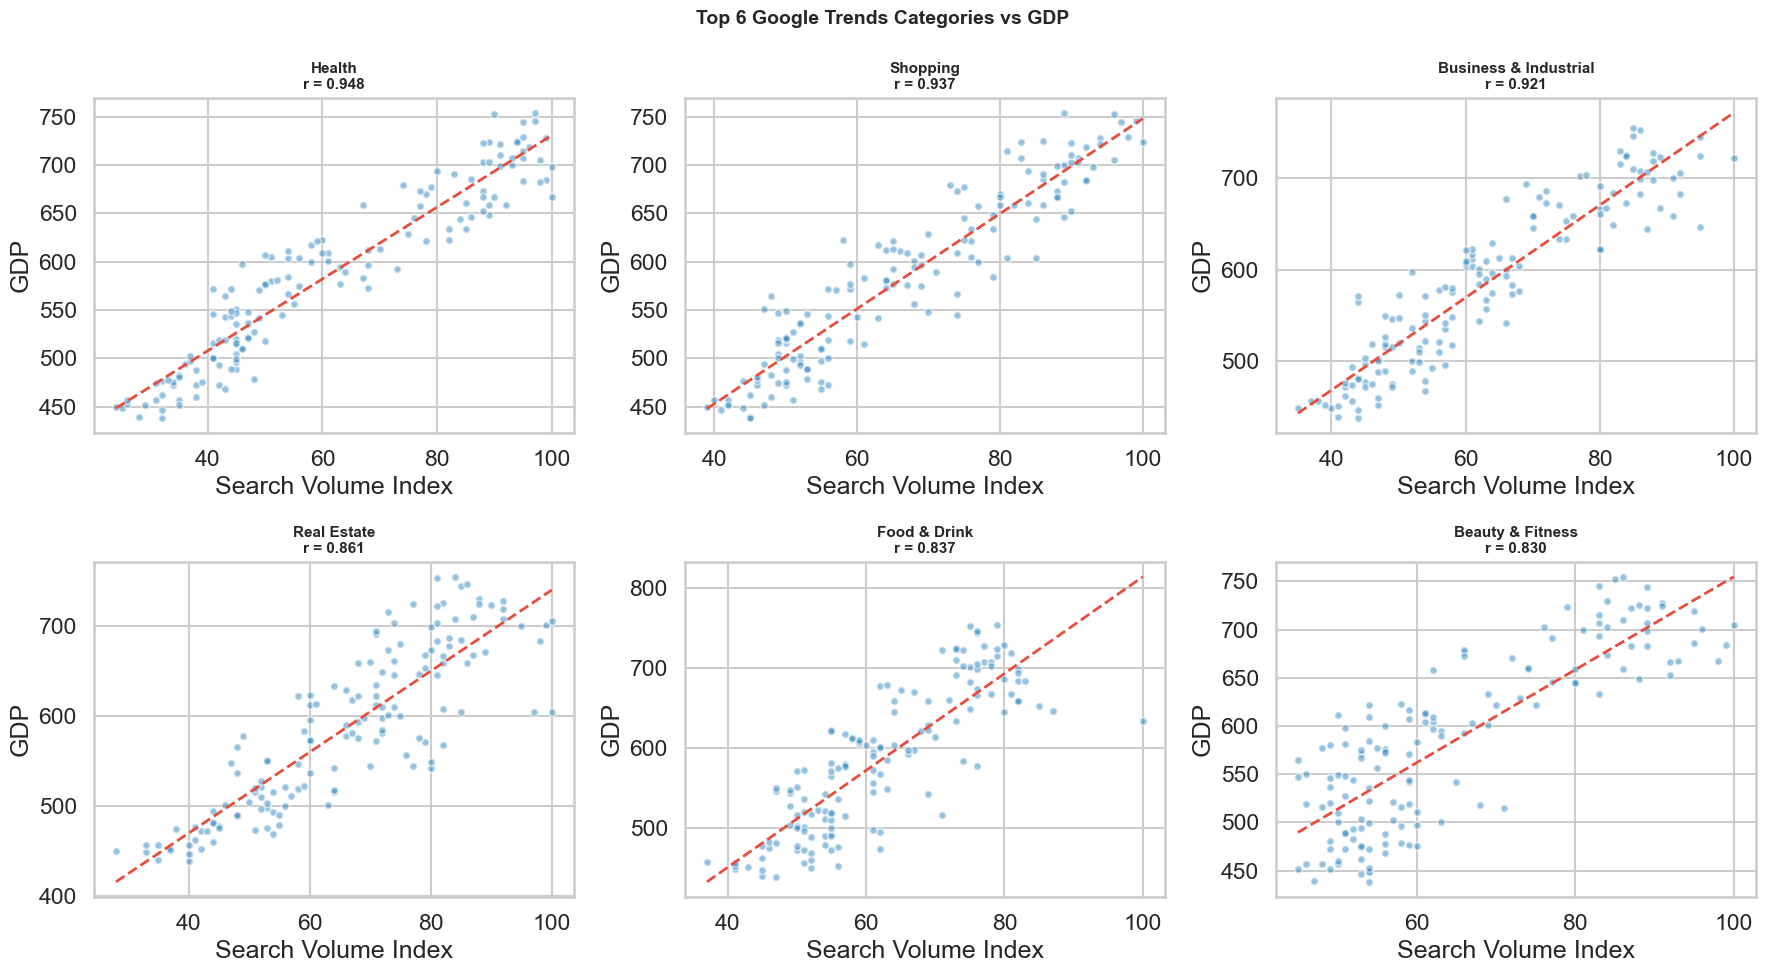

In [57]:
# CHART 3: Scatter — Top 6 categories vs GDP

# Get the 6 most correlated categories
top6 = corr_level.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, cat in zip(axes.flat, top6):

    # Scatter points
    ax.scatter(df_merged[cat], df_merged['Monthly GDP'],
               alpha=0.5, color='#2e86c1', s=30, edgecolors='white')
    
    # Trend line
    z = np.polyfit(df_merged[cat], df_merged['Monthly GDP'], 1)
    x_line = np.linspace(df_merged[cat].min(), df_merged[cat].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color='#e74c3c', linewidth=2, linestyle='--')
    
    # Title with correlation value
    r = df_merged[cat].corr(df_merged['Monthly GDP'])
    ax.set_title(f'{cat}\nr = {r:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Search Volume Index')
    ax.set_ylabel('GDP')

plt.suptitle('Top 6 Google Trends Categories vs GDP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

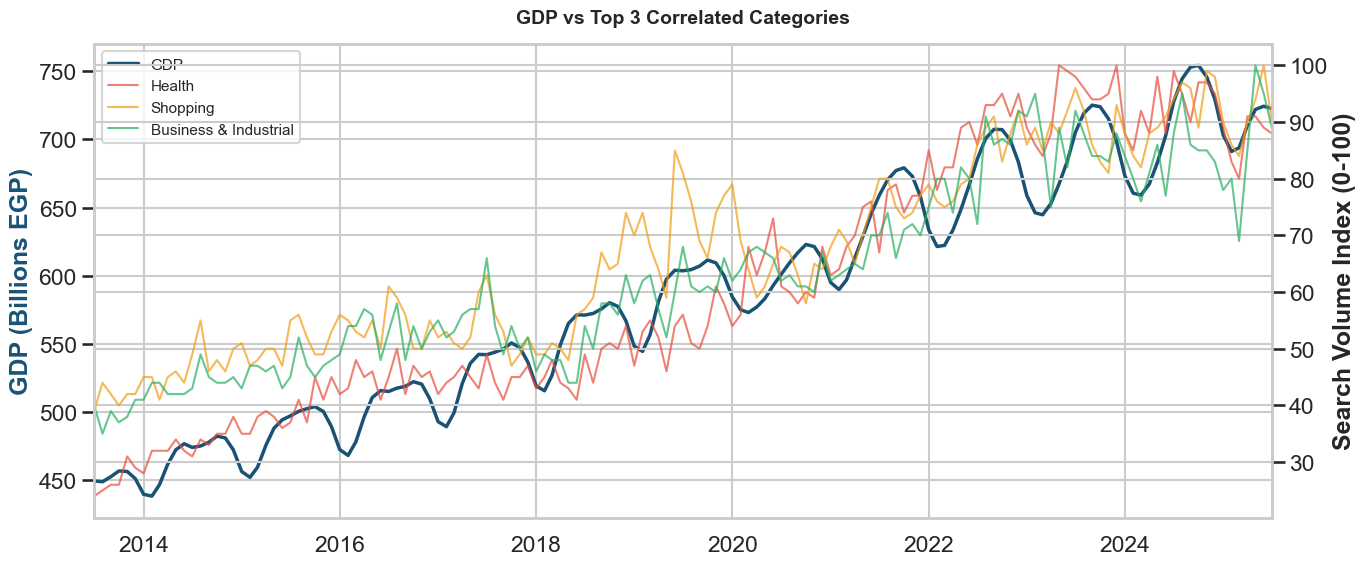

In [60]:
# CHART 4: GDP vs Top 3 categories over time

# Get the 3 most correlated categories
top3 = corr_level.abs().sort_values(ascending=False).head(3).index.tolist()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis — GDP
ax1.plot(df_merged.index, df_merged['Monthly GDP'],
         color='#1a5276', linewidth=2.5, label='GDP', zorder=3)
ax1.set_ylabel('GDP (Billions EGP)', color='#1a5276', fontweight='bold')

# Right axis — Top 3 Google Trends categories
ax2 = ax1.twinx()
line_colors = ['#e74c3c', '#f39c12', '#27ae60']

for cat, color in zip(top3, line_colors):
    ax2.plot(df_merged.index, df_merged[cat],
             color=color, linewidth=1.5, alpha=0.7, label=cat)

ax2.set_ylabel('Search Volume Index (0-100)', fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

# Styling
plt.title('GDP vs Top 3 Correlated Categories', fontsize=14, fontweight='bold', pad=15)
plt.margins(x=0)
plt.tight_layout()
plt.show()

In [53]:
# CHART 5: Stationarity Test
print("STATIONARITY TEST (Augmented Dickey-Fuller)")

for name, series in [('GDP Level', df_merged['Monthly GDP']),
                      ('GDP First Difference', df_merged['Monthly GDP'].diff().dropna())]:
    result = adfuller(series.dropna())
    print(f"\n{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Result:        {'✓ STATIONARY' if result[1] < 0.05 else '✗ NON-STATIONARY'}")

STATIONARITY TEST (Augmented Dickey-Fuller)

GDP Level:
  ADF Statistic: -0.6978
  p-value:       0.8473
  Result:        ✗ NON-STATIONARY

GDP First Difference:
  ADF Statistic: -2.8377
  p-value:       0.0531
  Result:        ✗ NON-STATIONARY


---

## Feature Engineering & Selection

#### Feature Engineering

In [ ]:
# Feature Engineering Process
df_features = df_merged.copy()
gt_categories = [col for col in df_features.columns if col not in ['Monthly GDP', 'MoM_Growth']]

In [ ]:
# Function to engineer features for any list of columns

def engineer_features(df, columns):
    for col in columns:
        # Lag features (1, 2, 3 months back)
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        
        # Rolling statistics (3-month window)
        df[f'{col}_ma3'] = df[col].rolling(3).mean()
        df[f'{col}_std3'] = df[col].rolling(3).std()
        
        # Month-over-month changes
        df[f'{col}_diff'] = df[col].diff()
        df[f'{col}_pct'] = df[col].pct_change()
    
    return df

In [ ]:
# Apply to all Google Trends categories
df_features = engineer_features(df_features, gt_categories)


In [ ]:
# Time features (seasonality encoding)
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

In [ ]:
# GDP autoregressive lags
for lag in [1, 2, 3]:
    df_features[f'gdp_lag{lag}'] = df_features['Monthly GDP'].shift(lag)

In [ ]:
# Drop NaN rows from shifting/rolling
rows_before = len(df_features)
df_features = df_features.dropna()

In [79]:
# Summary
print("FEATURE ENGINEERING SUMMARY")
print(f"Raw categories:      {len(gt_categories)}")
print(f"Total features:      {df_features.shape[1] - 2}")
print(f"Rows:                {df_features.shape[0]} (dropped {rows_before - len(df_features)})")

FEATURE ENGINEERING SUMMARY
Raw categories:      16
Total features:      134
Rows:                142 (dropped 3)


#### Feature Selection

In [80]:
# Prepare X (features) and y (target)
target = 'Monthly GDP'
exclude_cols = ['Monthly GDP', 'MoM_Growth']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

In [81]:
X = df_features[feature_cols]
y = df_features[target]

In [ ]:
# Scale for Lasso
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")

Features: 135  |  Samples: 142


In [84]:
# Method 1: Lasso — pushes useless features to zero

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso.coef_, index=feature_cols)

print(f"LASSO: Selected {(lasso_coefs != 0).sum()} / {len(feature_cols)} features")

LASSO: Selected 34 / 135 features


In [85]:
# Method 2: Mutual Information — captures non-linear relationships
mi_scores = mutual_info_regression(X, y, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print(f"MUTUAL INFORMATION: Top 5")
for feat, score in mi_series.head(5).items():
    print(f"  {feat:35s}  MI = {score:.4f}")

MUTUAL INFORMATION: Top 5
  gdp_lag1                             MI = 1.8936
  gdp_lag2                             MI = 1.3834
  Health_ma3                           MI = 1.2757
  Finance_ma3                          MI = 1.1598
  Health                               MI = 1.1469


In [86]:
# Method 3: Random Forest — tree-based importance
rf = RandomForestRegressor(n_estimators=500, max_depth=10,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(f"RANDOM FOREST: Top 5")
for feat, imp in rf_importance.head(5).items():
    print(f"  {feat:35s}  importance = {imp:.4f}")

RANDOM FOREST: Top 5
  gdp_lag1                             importance = 0.9012
  Beauty & Fitness_lag3                importance = 0.0130
  gdp_lag2                             importance = 0.0100
  Internet & Telecom_ma3               importance = 0.0099
  Internet & Telecom                   importance = 0.0082


In [87]:
# Consensus: Average rank across all 3 methods
consensus = pd.DataFrame({
    'Lasso': lasso_coefs.abs().rank(ascending=False),
    'MI': mi_series.rank(ascending=False),
    'RF': rf_importance.rank(ascending=False),
})
consensus['Avg'] = consensus.mean(axis=1)
consensus = consensus.sort_values('Avg')

In [88]:
# Select top 20
N_SELECT = 20
selected_features = consensus.head(N_SELECT).index.tolist()

In [ ]:
# Final dataset
df_selected = df_features[['Monthly GDP'] + selected_features]

print(f"CONSENSUS: Top {N_SELECT} Features Selected")
print(f"{'Feature':35s} {'Lasso':>7} {'MI':>7} {'RF':>7} {'Avg':>7}")
for feat in selected_features:
    row = consensus.loc[feat]
    print(f"{feat:35s} {row['Lasso']:7.0f} {row['MI']:7.0f} {row['RF']:7.0f} {row['Avg']:7.1f}")

print(f"\nFinal dataset: {df_selected.shape[0]} rows × {df_selected.shape[1]} columns")

CONSENSUS: Top 20 Features Selected
Feature                               Lasso      MI      RF     Avg
gdp_lag1                                  1       1       1     1.0
Health                                    3       5      30    12.7
Beauty & Fitness_lag3                     8      38       2    16.0
Beauty & Fitness_lag2                     9      31       9    16.3
Shopping_lag3                             4      25      47    25.3
gdp_lag2                                 85       2       3    30.0
Health_ma3                               85       3      10    32.7
Health_lag3                              85      12       6    34.3
Health_lag1                              85       6      14    35.0
Travel                                   12      67      27    35.3
People & Society_lag3                    30      51      26    35.7
Finance                                  14      20      74    36.0
Health_lag2                              85       8      16    36.3
Finance_lag3

---

## Model Creation

In [109]:
# Prepare data
X = df_selected[selected_features].values
y = df_selected['Monthly GDP'].values
dates = df_selected.index

In [110]:
# Define 3 models
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_child_weight=5, random_state=42, verbosity=0),
}

In [111]:
# Compare models using Time Series Cross-Validation

print("MODEL COMPARISON (5-Fold Time Series Cross Validation)")

# Track the best model by lowest MAE
best_name, best_mae = None, float('inf')

for name, model in models.items():
    
    # Create 5 time-ordered splits
    tscv = TimeSeriesSplit(n_splits=5)
    mae_scores, r2_scores = [], []
    
    for train_idx, test_idx in tscv.split(X):
        
        # Scale WITHIN each fold — prevents data leakage
        s = StandardScaler()
        
        # Clone creates a fresh copy of the model for each fold
        m = clone(model)
        
        # Train on past, predict the future
        m.fit(s.fit_transform(X[train_idx]), y[train_idx])
        pred = m.predict(s.transform(X[test_idx]))
        
        # Record performance for this fold
        mae_scores.append(mean_absolute_error(y[test_idx], pred))
        r2_scores.append(r2_score(y[test_idx], pred))
    
    # Average performance across all 5 folds
    avg_mae = np.mean(mae_scores)
    print(f"\n{name}:")
    print(f"  MAE: {avg_mae:.2f}  |  R²: {np.mean(r2_scores):.4f}")
    
    # Update best model if this one has lower MAE
    if avg_mae < best_mae:
        best_name, best_mae = name, avg_mae

print(f"\n Best model: {best_name}")

MODEL COMPARISON (5-Fold Time Series Cross Validation)

Ridge Regression:
  MAE: 17.78  |  R²: 0.2458

Random Forest:
  MAE: 30.13  |  R²: -0.8553

XGBoost:
  MAE: 23.14  |  R²: -0.1346

 Best model: Ridge Regression


In [112]:
# Rolling Backtest
# For each month: train on ALL previous months, predict the next one.

best_model = models[best_name]
predictions, actuals, pred_dates = [], [], []

for i in range(36, len(X)):
    
    # Fresh scaler and model for each step — no information leakage
    s = StandardScaler()
    m = clone(best_model)
    
    # Train on everything BEFORE month i
    m.fit(s.fit_transform(X[:i]), y[:i])
    
    # Predict ONLY month i (one step ahead)
    predictions.append(m.predict(s.transform(X[i:i+1]))[0])
    actuals.append(y[i])
    pred_dates.append(dates[i])

# Convert to arrays for metric calculation
predictions, actuals = np.array(predictions), np.array(actuals)
errors = actuals - predictions

# Final backtest performance
bt_mae = mean_absolute_error(actuals, predictions)
bt_r2 = r2_score(actuals, predictions)

print(f"ROLLING BACKTEST: {best_name}")
print(f"  MAE: {bt_mae:.2f}  |  R²: {bt_r2:.4f}")

ROLLING BACKTEST: Ridge Regression
  MAE: 7.91  |  R²: 0.9789


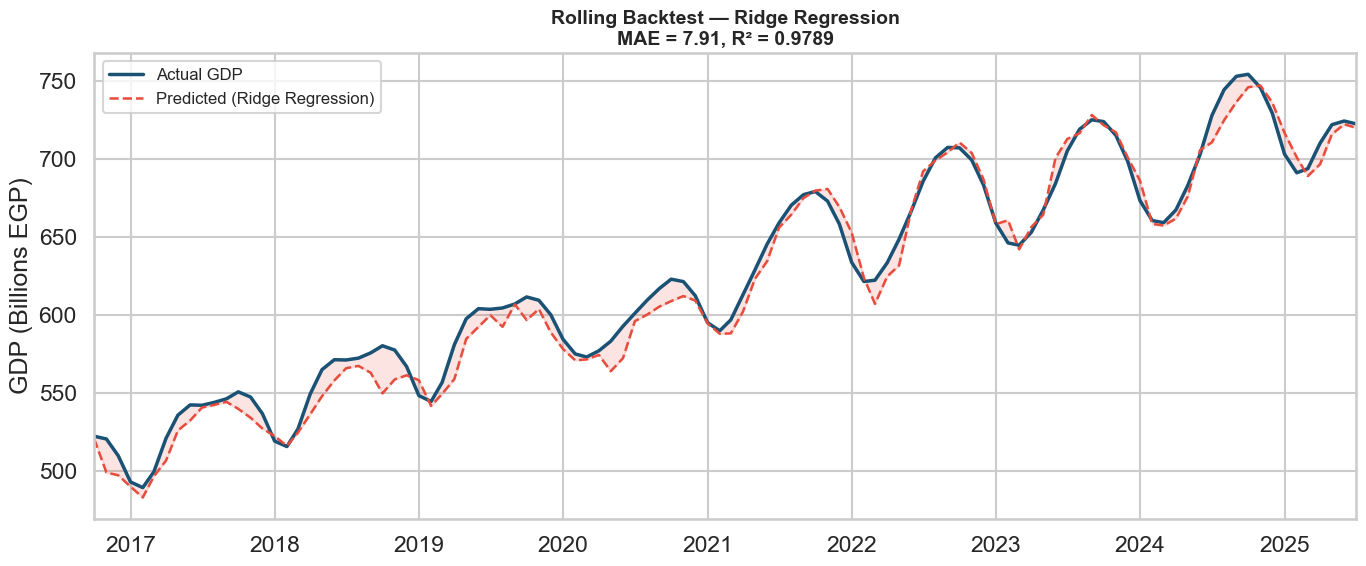

In [ ]:
# CHART: Actual vs Predicted
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(pred_dates, actuals, color='#1a5276', linewidth=2.5, label='Actual GDP')
ax.plot(pred_dates, predictions, color='#e74c3c', linewidth=1.8,
        linestyle='--', label=f'Predicted ({best_name})')

ax.fill_between(pred_dates, actuals, predictions, alpha=0.15, color='#e74c3c')

ax.set_title(f'Rolling Backtest — {best_name}\nMAE = {bt_mae:.2f}, R² = {bt_r2:.4f}',
             fontsize=14, fontweight='bold')
ax.set_ylabel('GDP (Billions EGP)')

ax.legend(fontsize=12)
plt.margins(x=0)
plt.tight_layout()
plt.show()

---

## Bonus Task

In [114]:
# Load & merge the 3 Arabic keyword files
keyword_files = {
    'gold_prices': '../data/gold_prices.csv',
    'car_market': '../data/car_market.csv',
    'investments': '../data/investments.csv',
}


In [115]:
# Load each Arabic keyword CSV using a loop
keyword_dfs = {}

for name, path in keyword_files.items():
    
    # Read the CSV file
    temp = pd.read_csv(path)
    
    # Rename columns from Arabic to English (e.g., 'أسعار الذهب اليوم' → 'gold_prices')
    temp.columns = ['date', name]
    
    # Convert date string to datetime and set as index (matching our other dataframes)
    temp['date'] = pd.to_datetime(temp['date'])
    temp = temp.sort_values('date').set_index('date')
    
    # Store in dictionary for easy access
    keyword_dfs[name] = temp

In [116]:
# Combine all keywords
df_keywords = keyword_dfs['gold_prices'].copy()
for name in ['car_market', 'investments']:
    df_keywords = df_keywords.merge(keyword_dfs[name], left_index=True, right_index=True, how='inner')

In [117]:
# Merge with our existing data
df_augmented = df_merged.merge(df_keywords, left_index=True, right_index=True, how='inner')
print(f"Augmented dataset: {df_augmented.shape}")

Augmented dataset: (145, 20)


In [118]:
# Re-run feature engineering on ALL columns including keywords
all_cols = [col for col in df_augmented.columns if col not in ['Monthly GDP', 'MoM_Growth']]
df_aug_feat = df_augmented.copy()
df_aug_feat = engineer_features(df_aug_feat, all_cols)

# Time & GDP features
df_aug_feat['month'] = df_aug_feat.index.month
df_aug_feat['quarter'] = df_aug_feat.index.quarter
df_aug_feat['month_sin'] = np.sin(2 * np.pi * df_aug_feat['month'] / 12)
df_aug_feat['month_cos'] = np.cos(2 * np.pi * df_aug_feat['month'] / 12)
for lag in [1, 2, 3]:
    df_aug_feat[f'gdp_lag{lag}'] = df_aug_feat['Monthly GDP'].shift(lag)

df_aug_feat = df_aug_feat.dropna()

In [119]:
# Feature selection on augmented data (original + Arabic keywords)


# Get all feature columns (exclude targets)
aug_feature_cols = [col for col in df_aug_feat.columns if col not in ['Monthly GDP', 'MoM_Growth']]

# Scale features — Lasso requires standardized inputs
scaler_aug = StandardScaler()
X_aug_scaled = pd.DataFrame(scaler_aug.fit_transform(df_aug_feat[aug_feature_cols]),
                             columns=aug_feature_cols, index=df_aug_feat.index)

# Run Lasso with 5-fold CV to auto-select the best regularization strength
lasso_aug = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_aug.fit(X_aug_scaled, df_aug_feat['Monthly GDP'])

# Extract non-zero coefficients (features Lasso kept) and sort by importance
lasso_aug_coefs = pd.Series(lasso_aug.coef_, index=aug_feature_cols)
lasso_aug_selected = lasso_aug_coefs[lasso_aug_coefs != 0].sort_values(key=abs, ascending=False)

# Take top 20 features for the augmented model
aug_selected = lasso_aug_selected.head(20).index.tolist()

In [121]:
# Show which new keywords made it
new_keywords = ['gold_prices', 'car_market', 'investments']
print(f"\nLasso selected {len(lasso_aug_selected)} features. Top 20:")
for i, (feat, coef) in enumerate(lasso_aug_selected.head(20).items()):
    marker = " NEW" if any(kw in feat for kw in new_keywords) else ""
    print(f"  {i+1:2d}. {feat:35s} {coef:+.4f}{marker}")



Lasso selected 41 features. Top 20:
   1. gdp_lag1                            +70.6115
   2. month_cos                           -9.5250
   3. Health                              +4.8228
   4. Shopping_lag3                       +4.7695
   5. Arts & Entertainment                -3.7841
   6. quarter                             +2.1864
   7. Arts & Entertainment_lag1           -1.8871
   8. Beauty & Fitness_lag3               +1.6015
   9. Jobs & Education_std3               +1.3041
  10. Food & Drink_std3                   -1.2118
  11. Beauty & Fitness_lag2               +1.1964
  12. Shopping_std3                       -0.8759
  13. Beauty & Fitness_std3               -0.8237
  14. People & Society_std3               +0.7107
  15. Travel_std3                         +0.6967
  16. People & Society_lag3               +0.6455
  17. People & Society_diff               -0.6358
  18. gold_prices_std3                    -0.6355 NEW
  19. gold_prices_pct                     -0.6266 NEW
  20

In [122]:
# Rolling backtest — augmented model (with Arabic keywords)
X_aug = df_aug_feat[aug_selected].values
y_aug = df_aug_feat['Monthly GDP'].values
dates_aug = df_aug_feat.index

preds_aug, acts_aug, dates_bt_aug = [], [], []

for i in range(36, len(X_aug)):
    
    # Same procedure: fresh scaler + model, train on past, predict next
    s = StandardScaler()
    m = clone(Ridge(alpha=1.0))
    m.fit(s.fit_transform(X_aug[:i]), y_aug[:i])
    
    preds_aug.append(m.predict(s.transform(X_aug[i:i+1]))[0])
    acts_aug.append(y_aug[i])
    dates_bt_aug.append(dates_aug[i])

# Convert and calculate metrics
preds_aug, acts_aug = np.array(preds_aug), np.array(acts_aug)
errors_aug = acts_aug - preds_aug

bt_mae_aug = mean_absolute_error(acts_aug, preds_aug)
bt_r2_aug = r2_score(acts_aug, preds_aug)

In [123]:
# Compare: Before vs After
print("BEFORE vs AFTER Arabic Keywords")
print(f"{'':>10}  {'Without':>10}  {'With':>10}  {'Change':>10}")
print(f"{'MAE':>10}  {bt_mae:10.2f}  {bt_mae_aug:10.2f}  {bt_mae_aug - bt_mae:+10.2f}")
print(f"{'R²':>10}  {bt_r2:10.4f}  {bt_r2_aug:10.4f}  {bt_r2_aug - bt_r2:+10.4f}")


BEFORE vs AFTER Arabic Keywords
               Without        With      Change
       MAE        7.91        5.67       -2.25
        R²      0.9789      0.9897     +0.0108


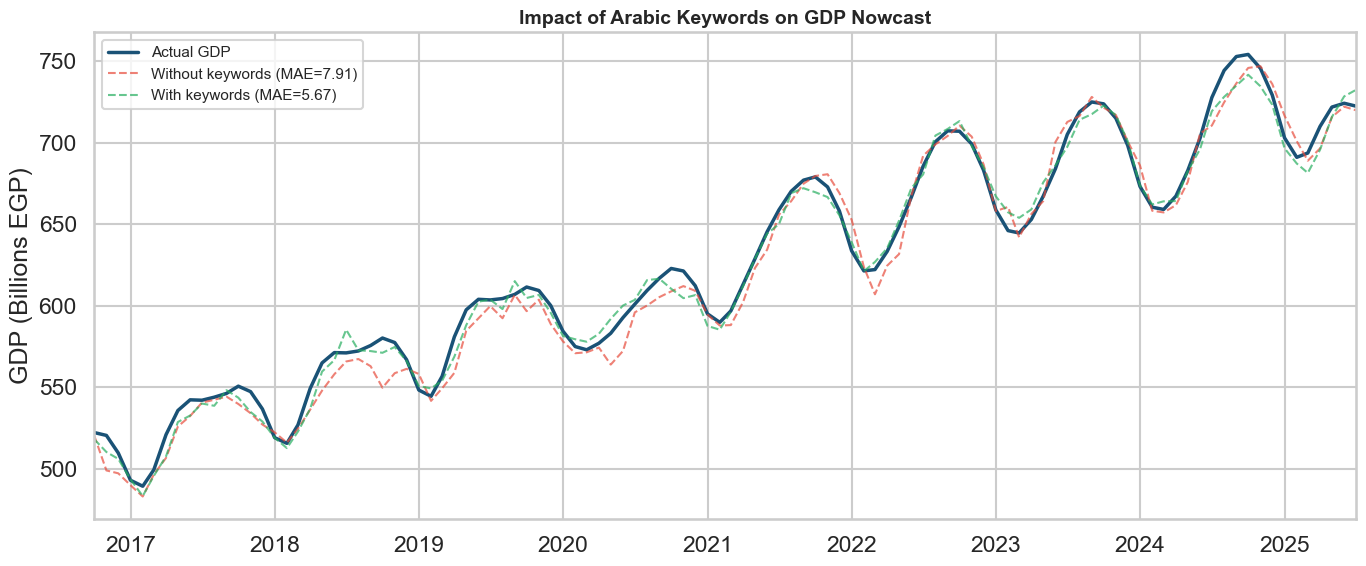

In [124]:
# CHART: Before vs After
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_bt_aug, acts_aug, color='#1a5276', linewidth=2.5, label='Actual GDP')
ax.plot(pred_dates, predictions, color='#e74c3c', linewidth=1.5,
        linestyle='--', alpha=0.7, label=f'Without keywords (MAE={bt_mae:.2f})')
ax.plot(dates_bt_aug, preds_aug, color='#27ae60', linewidth=1.5,
        linestyle='--', alpha=0.7, label=f'With keywords (MAE={bt_mae_aug:.2f})')

ax.set_title('Impact of Arabic Keywords on GDP Nowcast', fontsize=14, fontweight='bold')
ax.set_ylabel('GDP (Billions EGP)')

ax.legend(fontsize=11)
plt.margins(x=0)
plt.tight_layout()
plt.show()

---